### R6 - NeuralNetwork and Deep Learning : Project 2 - The Street View House Numbers (SVHN) Dataset

Data Set Reference: https://drive.google.com/file/d/1L2-WXzguhUsCArrFUc8EEkXcj33pahoS/view?usp=sharing 

In [0]:
# import numpy and pandas library
import numpy as np
import pandas as pd

In [0]:
from sklearn.model_selection import train_test_split
# calculate accuracy measures and confusion matrix
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc,roc_curve

In [0]:
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

In [45]:
import h5py
import tensorflow as tf
import keras

Using TensorFlow backend.


In [0]:
import warnings 
warnings.filterwarnings('ignore')

### Questions :

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [0]:
h5FilePath="/content/drive/My Drive/GL-PGPAIML/Project/R6_NN-DL_Project2/SVHN_single_grey1.h5"

### 1. Read the dataset

In [0]:
#Read SVHN data from h5 file
svhn_h5f = h5py.File(h5FilePath,"r")

In [50]:
#Get Keys from h5py object
keys=svhn_h5f.keys()
for key in keys:
    print(key)

X_test
X_train
X_val
y_test
y_train
y_val


In [0]:
#Get Train, Test and Validation data along with Label
X_train=svhn_h5f['X_train'][:]
y_train=svhn_h5f['y_train'][:]

X_test=svhn_h5f['X_test'][:]
y_test=svhn_h5f['y_test'][:]

X_val=svhn_h5f['X_val'][:]
y_val=svhn_h5f['y_val'][:]

In [56]:
#Get Train Y label unique value
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [57]:
#Get Test Y label unique value
np.unique(y_test)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [58]:
#Get Test Y label unique value
np.unique(y_val)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [0]:
#Close h5 file
svhn_h5f.close()

In [54]:
print("Training Set",X_train.shape, y_train.shape )
print("Validation Set",X_val.shape, y_val.shape )
print("Test Set",X_test.shape, y_test.shape )

Training Set (42000, 32, 32) (42000,)
Validation Set (60000, 32, 32) (60000,)
Test Set (18000, 32, 32) (18000,)


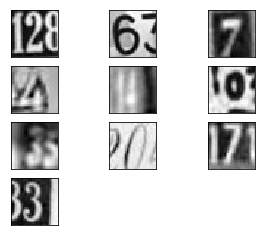

label for each of the above image:
 [2, 6, 7, 4, 4, 0, 3, 0, 7, 3]


In [55]:
# Visualize first 10 train data with label
labels = []

plt.figure(figsize=(5,5))
for i in range(10):
    plt.subplot(5,3,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.get_cmap('gray'))
    lbl=y_train[i]
    labels.append(lbl)
plt.show()
print("label for each of the above image:\n", labels)

### 2. Convert train, test and validation data labels to one hot vectors

In [0]:
num_classes = 10 # No. of unique Label in the dataset (From 1 to 10)
# Convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)

In [61]:
print(y_train.shape)
print('First 5 examples now are: \n', y_train[0:5])

(42000, 10)
First 5 examples now are: 
 [[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


### 3. Normalize the Train, Test and Validation image data from 0-255 to 0-1

In [0]:
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255
X_val = X_val.astype('float32') / 255

### 4. Reshape the data from 32x32 to 32x32x1 to match input dimensions in Conv2D layer in keras

In [0]:
# reshape dataset to have a single channel
X_train = X_train.reshape((X_train.shape[0], 32, 32, 1))
X_test = X_test.reshape((X_test.shape[0], 32, 32, 1))
X_val = X_val.reshape((X_val.shape[0], 32, 32, 1))

In [64]:
print("Training Set",X_train.shape )
print("Validation Set",X_val.shape )
print("Test Set",X_test.shape )

Training Set (42000, 32, 32, 1)
Validation Set (60000, 32, 32, 1)
Test Set (18000, 32, 32, 1)


### 5. Build Model

#### Model1: (Base Model)

 1. Let's build base model (model1) with 1 Conv layers having `32 3x3 filters` `relu activations` and 
 2. `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. 
 3. Compile Model1 using `categorical_crossentropy` loss with `sgd` optimizer.
 4. And finally fit model 10 Epochs and 32 Batch Size. 

In [0]:
#Initialize model1
model1 = tf.keras.models.Sequential()

In [0]:
model1.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(32, 32, 1)))
model1.add(tf.keras.layers.Flatten())
#Add - Dense Layer - 128 Nurons with Relu
model1.add(tf.keras.layers.Dense(128, activation='relu'))
#Add - Dense Layer/output layer - 10 Nurons with Softmax
model1.add(tf.keras.layers.Dense(10, activation='softmax'))

In [0]:
# compile model
model1.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [76]:
# Fit the model1 with 10 epochs and batch size 32 for train and validation data
m1_history=model1.fit(X_train, y_train, 
          validation_data=(X_val, y_val), 
          epochs=10,
          batch_size=32)

Train on 42000 samples, validate on 60000 samples
Epoch 1/10
42000/42000 [==============================] - 66s 2ms/sample - loss: 2.2521 - acc: 0.1830 - val_loss: 2.0587 - val_acc: 0.3280
Epoch 2/10
42000/42000 [==============================] - 66s 2ms/sample - loss: 1.5868 - acc: 0.5025 - val_loss: 1.3540 - val_acc: 0.5812
Epoch 3/10
42000/42000 [==============================] - 65s 2ms/sample - loss: 1.1759 - acc: 0.6402 - val_loss: 1.1430 - val_acc: 0.6375
Epoch 4/10
42000/42000 [==============================] - 66s 2ms/sample - loss: 1.0528 - acc: 0.6803 - val_loss: 1.0562 - val_acc: 0.6773
Epoch 5/10
42000/42000 [==============================] - 66s 2ms/sample - loss: 0.9678 - acc: 0.7069 - val_loss: 0.9986 - val_acc: 0.6922
Epoch 6/10
42000/42000 [==============================] - 65s 2ms/sample - loss: 0.9078 - acc: 0.7246 - val_loss: 0.9806 - val_acc: 0.7042
Epoch 7/10
42000/42000 [==============================] - 67s 2ms/sample - loss: 0.8518 - acc: 0.7441 - val_loss: 0.

In [77]:
# list all data in history
print(m1_history.history.keys())

dict_keys(['loss', 'acc', 'val_loss', 'val_acc'])


### Plot Model1 Fit output for Train & Validation Data

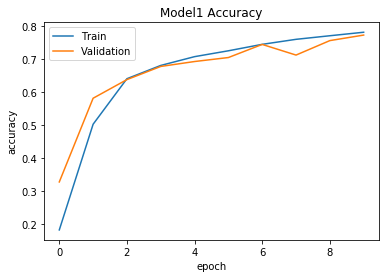

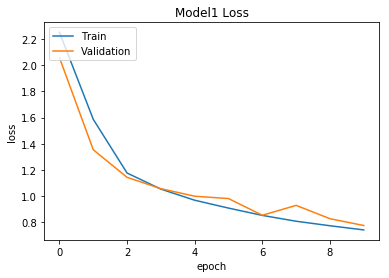

In [80]:

# summarize history for accuracy
plt.plot(m1_history.history['acc'])
plt.plot(m1_history.history['val_acc'])
plt.title('Model1 Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(m1_history.history['loss'])
plt.plot(m1_history.history['val_loss'])
plt.title('Model1 Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### Evaluate Model1 with Test Data:

In [82]:
model1_result=model1.evaluate(X_test,y_test,verbose=1)

18000/18000 [==============================] - 5s 284us/sample - loss: 0.8375 - acc: 0.7576


In [83]:
print("Model1 Accuracy : {0}".format(model1_result[1]*100))

Model Accuracy : 75.75555443763733


In [95]:
print("Model1 Loss : {0}".format(model1_result[0]))

Model1 Loss : 0.8375326020452711


### Model1 Summary:

In [81]:
### Model Summary:

model1.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 30, 30, 32)        320       
_________________________________________________________________
flatten_1 (Flatten)          (None, 28800)             0         
_________________________________________________________________
dense_2 (Dense)              (None, 128)               3686528   
_________________________________________________________________
dense_3 (Dense)              (None, 10)                1290      
Total params: 3,688,138
Trainable params: 3,688,138
Non-trainable params: 0
_________________________________________________________________


#### Model2: 

 1. Let's build base model (model2) with 1 Conv layers having `32 3x3 filters` `relu activations` and 
 2. `flatten` before passing the feature map into 3 fully connected layers (or Dense Layers) having 2x128 dense layers ith 'Relu'
 3. 10 neurons with `relu` and `softmax` activations respectively. 
 4. Compile Model1 using `categorical_crossentropy` loss with `Adam` optimizer.
 5. And finally fit model 10 Epochs and 32 Batch Size.

In [0]:
#Initialize model1
model2 = tf.keras.models.Sequential()

In [0]:
model2.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(32, 32, 1)))
model2.add(tf.keras.layers.Flatten())
#Add - Dense Layer - 128 Nurons with Relu
model2.add(tf.keras.layers.Dense(128, activation='relu'))
#Add - Dense Layer - 128 Nurons with Relu
model2.add(tf.keras.layers.Dense(128, activation='relu'))
#Add - Dense Layer/output layer - 10 Nurons with Softmax
model2.add(tf.keras.layers.Dense(10, activation='softmax'))

In [0]:
# compile model
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [90]:
# Fit the model1 with 10 epochs and batch size 32 for train and validation data
m2_history=model2.fit(X_train, y_train, 
          validation_data=(X_val, y_val), 
          epochs=10,
          batch_size=32)

Train on 42000 samples, validate on 60000 samples
Epoch 1/10
42000/42000 [==============================] - 76s 2ms/sample - loss: 1.1201 - acc: 0.6379 - val_loss: 0.6751 - val_acc: 0.8000
Epoch 2/10
42000/42000 [==============================] - 76s 2ms/sample - loss: 0.5765 - acc: 0.8316 - val_loss: 0.5495 - val_acc: 0.8361
Epoch 3/10
42000/42000 [==============================] - 76s 2ms/sample - loss: 0.4792 - acc: 0.8553 - val_loss: 0.4473 - val_acc: 0.8675
Epoch 4/10
42000/42000 [==============================] - 77s 2ms/sample - loss: 0.4146 - acc: 0.8734 - val_loss: 0.4281 - val_acc: 0.8723
Epoch 5/10
42000/42000 [==============================] - 77s 2ms/sample - loss: 0.3653 - acc: 0.8880 - val_loss: 0.3765 - val_acc: 0.8900
Epoch 6/10
42000/42000 [==============================] - 76s 2ms/sample - loss: 0.3242 - acc: 0.9000 - val_loss: 0.3434 - val_acc: 0.8986
Epoch 7/10
42000/42000 [==============================] - 77s 2ms/sample - loss: 0.2916 - acc: 0.9090 - val_loss: 0.

### Plot Model2 Fit output for Train & Validation Data

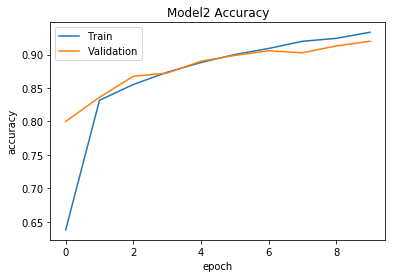

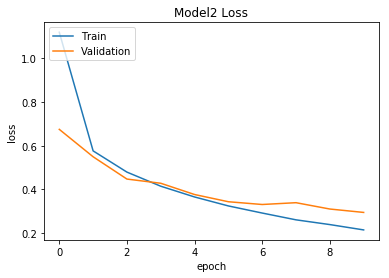

In [102]:
# summarize history for accuracy
plt.plot(m2_history.history['acc'])
plt.plot(m2_history.history['val_acc'])
plt.title('Model2 Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(m2_history.history['loss'])
plt.plot(m2_history.history['val_loss'])
plt.title('Model2 Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### Evaluate Model2 with Test Data

In [92]:
model2_result=model2.evaluate(X_test,y_test,verbose=1)

18000/18000 [==============================] - 5s 287us/sample - loss: 0.5744 - acc: 0.8584


In [96]:
print("Model2 - Test Data Accuracy : {0}".format(model2_result[1]*100))
print("Model2 - Test Data Loss : {0}".format(model2_result[0]))

Model2 - Test Data Accuracy : 85.84444522857666
Model2 - Test Data Loss : 0.5743558861513932


### Model-2 Summary:

In [97]:
model2.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_2 (Conv2D)            (None, 30, 30, 32)        320       
_________________________________________________________________
flatten_2 (Flatten)          (None, 28800)             0         
_________________________________________________________________
dense_4 (Dense)              (None, 128)               3686528   
_________________________________________________________________
dense_5 (Dense)              (None, 128)               16512     
_________________________________________________________________
dense_6 (Dense)              (None, 10)                1290      
Total params: 3,704,650
Trainable params: 3,704,650
Non-trainable params: 0
_________________________________________________________________


#### Model3: 

 1. Let's build base model (model3) with 2 Conv layers having `32 3x3 filters` and '64 32x32' with `relu activations` 
 2. Then MaxPool with size 2 and 25% dropout Layer
 2. `flatten` before passing the feature map into 3 fully connected layers (or Dense Layers) having 2x128 dense layers ith 'Relu'
 3. 10 neurons with `relu` and `softmax` activations respectively. 
 4. Compile Model1 using `categorical_crossentropy` loss with `Adam` optimizer.
 5. And finally fit model 10 Epochs and 32 Batch Size.

In [0]:
#Initialize model1
model3 = tf.keras.models.Sequential()

In [0]:
model3.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(32, 32, 1)))
model3.add(tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model3.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))
model3.add(tf.keras.layers.Dropout(0.25))
model3.add(tf.keras.layers.Flatten())
#Add - Dense Layer - 128 Nurons with Relu
model3.add(tf.keras.layers.Dense(128, activation='relu'))
#Add - Dense Layer - 128 Nurons with Relu
model3.add(tf.keras.layers.Dense(128, activation='relu'))
#Add - Dense Layer/output layer - 10 Nurons with Softmax
model3.add(tf.keras.layers.Dense(10, activation='softmax'))

In [0]:
# compile model
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [101]:
# Fit the model1 with 10 epochs and batch size 32 for train and validation data
m3_history=model3.fit(X_train, y_train, 
          validation_data=(X_val, y_val), 
          epochs=10,
          batch_size=32)

Train on 42000 samples, validate on 60000 samples
Epoch 1/10
42000/42000 [==============================] - 194s 5ms/sample - loss: 0.9957 - acc: 0.6808 - val_loss: 0.5135 - val_acc: 0.8540
Epoch 2/10
42000/42000 [==============================] - 196s 5ms/sample - loss: 0.5117 - acc: 0.8513 - val_loss: 0.4383 - val_acc: 0.8727
Epoch 3/10
42000/42000 [==============================] - 194s 5ms/sample - loss: 0.4274 - acc: 0.8724 - val_loss: 0.3626 - val_acc: 0.8929
Epoch 4/10
42000/42000 [==============================] - 194s 5ms/sample - loss: 0.3631 - acc: 0.8880 - val_loss: 0.2979 - val_acc: 0.9149
Epoch 5/10
42000/42000 [==============================] - 196s 5ms/sample - loss: 0.3201 - acc: 0.9013 - val_loss: 0.2740 - val_acc: 0.9223
Epoch 6/10
42000/42000 [==============================] - 198s 5ms/sample - loss: 0.2826 - acc: 0.9119 - val_loss: 0.2528 - val_acc: 0.9269
Epoch 7/10
42000/42000 [==============================] - 200s 5ms/sample - loss: 0.2494 - acc: 0.9220 - val_l

### Plot Model 3 Fit output for Train & Validation Data

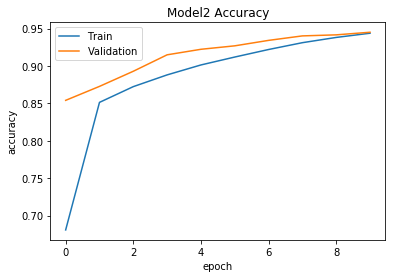

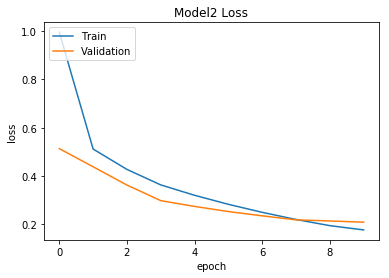

In [103]:
# summarize history for accuracy
plt.plot(m3_history.history['acc'])
plt.plot(m3_history.history['val_acc'])
plt.title('Model2 Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(m3_history.history['loss'])
plt.plot(m3_history.history['val_loss'])
plt.title('Model2 Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### Evaluate Model 3 with Test Data

In [104]:
model3_result=model3.evaluate(X_test,y_test,verbose=1)
print("Model3 - Test Data Accuracy : {0}".format(model3_result[1]*100))
print("Model3 - Test Data Loss : {0}".format(model3_result[0]))

18000/18000 [==============================] - 15s 837us/sample - loss: 0.4147 - acc: 0.8909
Model3 - Test Data Accuracy : 89.09444212913513
Model3 - Test Data Loss : 0.4146811460587713


### Model 3 Summary:

In [105]:
model3.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_3 (Conv2D)            (None, 30, 30, 32)        320       
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 28, 28, 64)        18496     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 14, 14, 64)        0         
_________________________________________________________________
dropout (Dropout)            (None, 14, 14, 64)        0         
_________________________________________________________________
flatten_3 (Flatten)          (None, 12544)             0         
_________________________________________________________________
dense_7 (Dense)              (None, 128)               1605760   
_________________________________________________________________
dense_8 (Dense)              (None, 10)               

### Model Results:

In [0]:
SVHN_model_Result=pd.DataFrame(index=["Model Name","Test Data Accuracy","Test Data Loss"])
SVHN_model_Result["Model1"]=["Model1",("%0.2f" % ((model1_result[1]*100))),("%0.2f" % ((model1_result[0])))]
SVHN_model_Result["Model2"]=["Model2",("%0.2f" % ((model2_result[1]*100))),("%0.2f" % ((model2_result[0])))]
SVHN_model_Result["Model3"]=["Model3",("%0.2f" % ((model3_result[1]*100))),("%0.2f" % ((model3_result[0])))]

In [114]:
SVHN_model_Result

,Model1,Model2,Model3
Model Name,Model1,Model2,Model3
Test Data Accuracy,75.76,85.84,89.09
Test Data Loss,0.84,0.57,0.41


## Final Summary:



1.   In  given Street View House Numbers (SVHN) Dataset, we have below shape in the Train, Test and Validation dataset:

      Train Data : (42000, 32, 32)
      
      Test Data  :(60000, 32, 32)
      
      Validation : (18000, 32, 32)
2.   In the given data we have label value (output) from 1 to 10 in all the set.

3.  We have done one hot encoder and reshape the data to (32x32x1).
4.  We have built 3 model and evaluated with test data, when we look each model result Model 3 has been given better accuracy (89.09 %) for test data.

